# Notebook 02 — Exploratory Data Analysis

**Input:** `public/data/panel.json` (from Notebook 01)

This notebook explores the panel dataset through:
1. Distributions of key variables
2. Time series trends (days-to-feed, wages, prices)
3. Regional comparisons (heatmaps, box plots)
4. Correlation analysis
5. Outlier detection

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

PANEL_PATH = Path("../public/data/panel.json")
with open(PANEL_PATH) as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df["date"] = pd.to_datetime(df["month"])
print(f"Panel: {df.shape[0]} rows, {df['region'].nunique()} regions, {df['month'].nunique()} months")
print(f"Date range: {df['month'].min()} → {df['month'].max()}")
df.head()

Panel: 1700 rows, 17 regions, 100 months
Date range: 2018-01 → 2026-04


,region,month,rice_price,rice_wm_price,egg_price,fish_price,pork_price,cpi_all,cpi_b30,daily_wage,household_size,daily_basket_pp,daily_basket_hh,monthly_basket,days_to_feed,real_wage,rice_share,wage_basket_gap,date
0,NCR,2018-01,37.26,43.80,5.77,159.84,262.34,96.9,96.7,500.0,3.83,86.8000,332.4440,9973.3200,19.9466,515.9959,0.1717,167.5560,2018-01-01
1,NCR,2018-02,37.42,43.94,5.76,161.74,265.17,98.0,97.7,500.0,3.83,87.6675,335.7665,10072.9958,20.1460,510.2041,0.1707,164.2335,2018-02-01
2,NCR,2018-03,38.03,44.17,5.61,171.16,265.40,99.0,98.9,500.0,3.83,89.8150,343.9914,10319.7435,20.6395,505.0505,0.1694,156.0086,2018-03-01
3,NCR,2018-04,38.07,44.19,5.49,172.32,265.87,99.3,99.1,500.0,3.83,90.1215,345.1653,10354.9604,20.7099,503.5247,0.1690,154.8347,2018-04-01
4,NCR,2018-05,37.92,44.34,5.36,169.98,267.56,99.2,98.9,500.0,3.83,89.8340,344.0642,10321.9266,20.6439,504.0323,0.1688,155.9358,2018-05-01


## 1. Distributions of Key Variables

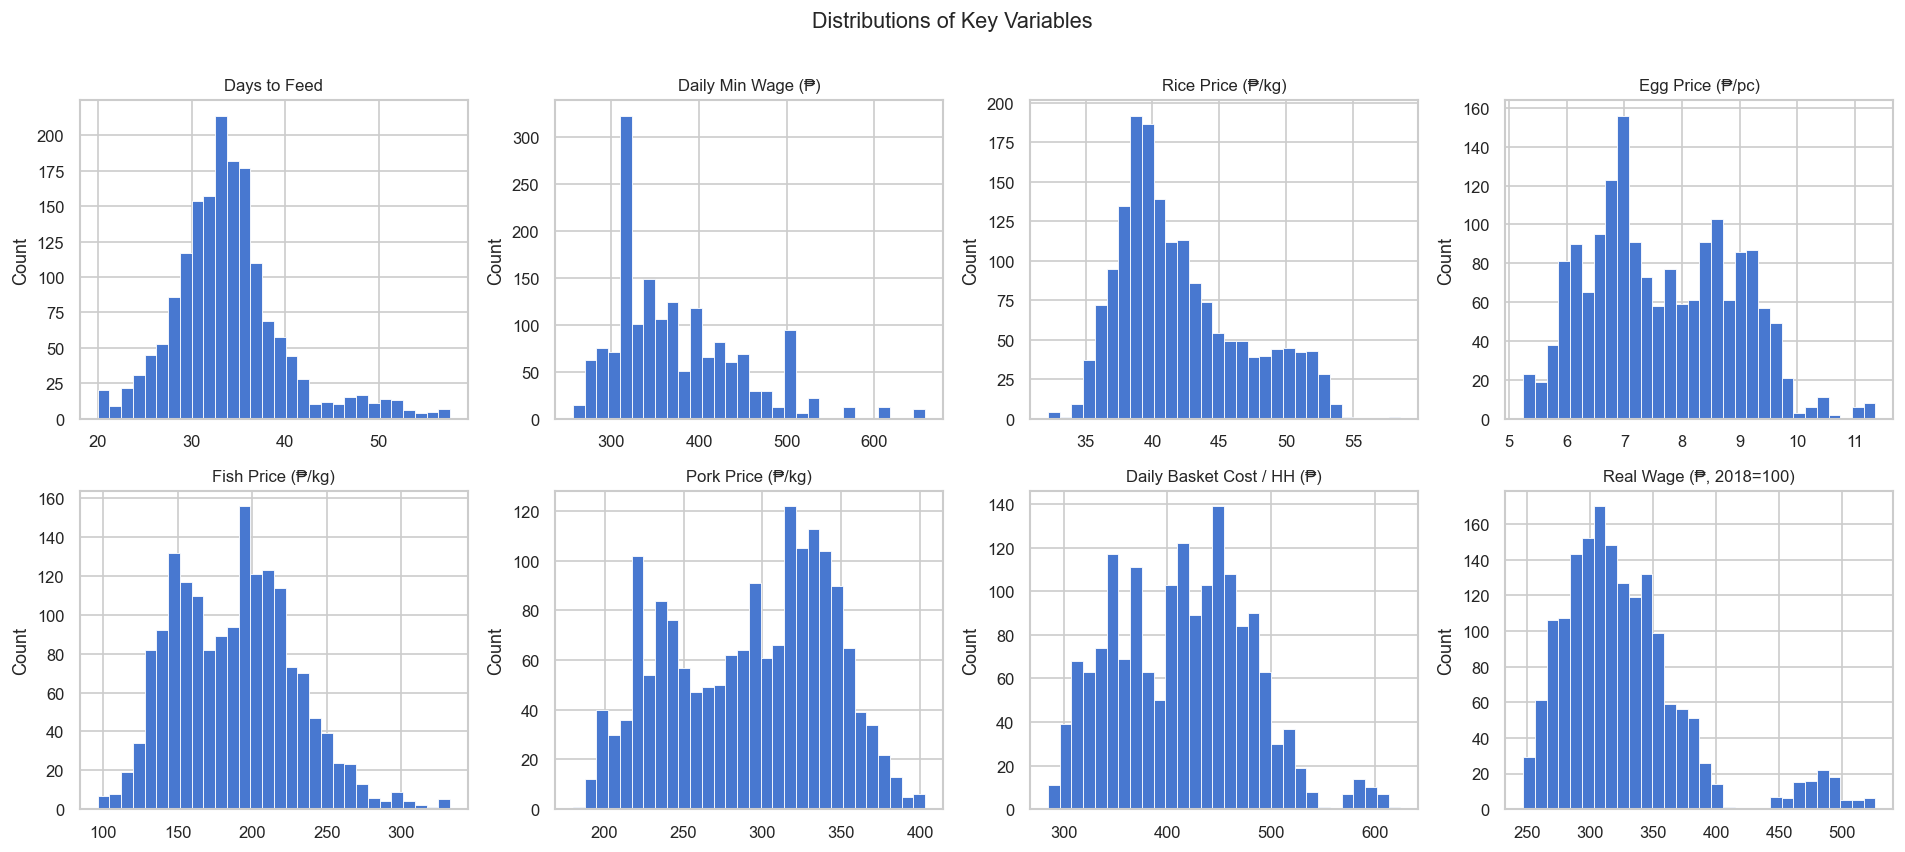

In [2]:
vars_to_plot = ["days_to_feed", "daily_wage", "rice_price", "egg_price",
                 "fish_price", "pork_price", "daily_basket_hh", "real_wage"]
labels = {
    "days_to_feed": "Days to Feed",
    "daily_wage": "Daily Min Wage (₱)",
    "rice_price": "Rice Price (₱/kg)",
    "egg_price": "Egg Price (₱/pc)",
    "fish_price": "Fish Price (₱/kg)",
    "pork_price": "Pork Price (₱/kg)",
    "daily_basket_hh": "Daily Basket Cost / HH (₱)",
    "real_wage": "Real Wage (₱, 2018=100)",
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, var in zip(axes.flat, vars_to_plot):
    ax.hist(df[var].dropna(), bins=30, edgecolor="white", linewidth=0.5)
    ax.set_title(labels.get(var, var), fontsize=10)
    ax.set_ylabel("Count")
fig.suptitle("Distributions of Key Variables", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 2. Time Series — Days to Feed by Region

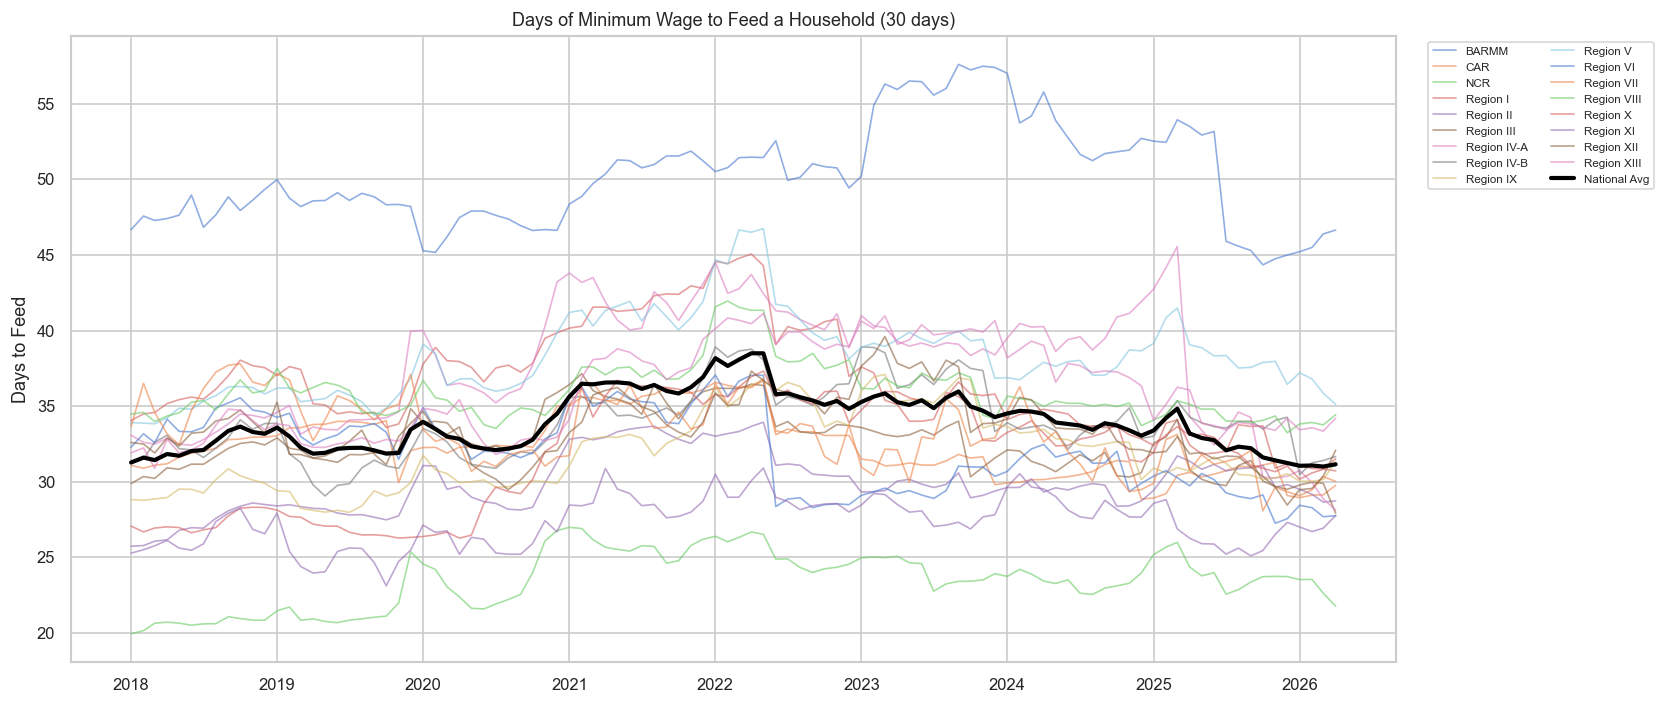

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
for region, grp in df.groupby("region"):
    grp_sorted = grp.sort_values("date")
    ax.plot(grp_sorted["date"], grp_sorted["days_to_feed"], alpha=0.6, linewidth=1, label=region)

national = df.groupby("date")["days_to_feed"].mean().reset_index()
ax.plot(national["date"], national["days_to_feed"], color="black", linewidth=2.5, label="National Avg", zorder=10)

ax.set_title("Days of Minimum Wage to Feed a Household (30 days)")
ax.set_ylabel("Days to Feed")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

## 3. Wage vs. Food Cost Trends

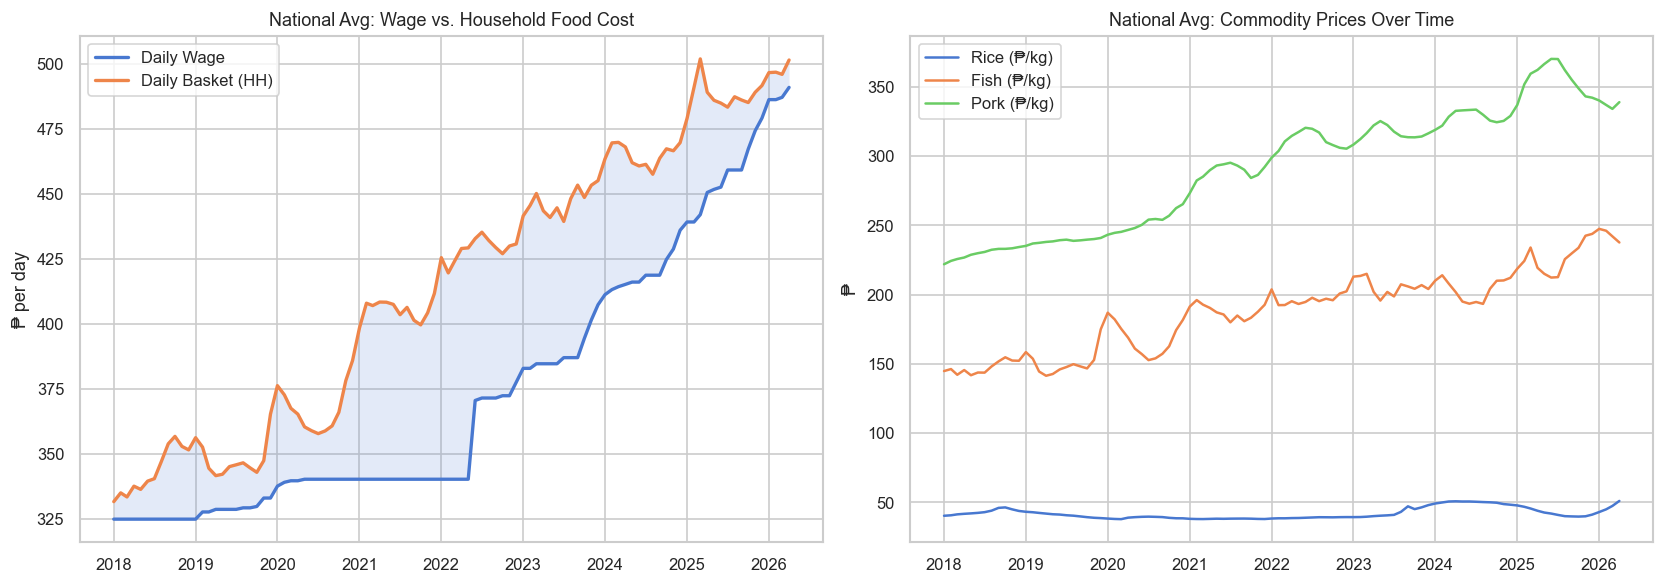

In [4]:
nat = df.groupby("date").agg(
    daily_wage=("daily_wage", "mean"),
    daily_basket_hh=("daily_basket_hh", "mean"),
    rice_price=("rice_price", "mean"),
    fish_price=("fish_price", "mean"),
    pork_price=("pork_price", "mean"),
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(nat["date"], nat["daily_wage"], label="Daily Wage", linewidth=2)
ax1.plot(nat["date"], nat["daily_basket_hh"], label="Daily Basket (HH)", linewidth=2)
ax1.fill_between(nat["date"], nat["daily_basket_hh"], nat["daily_wage"], alpha=0.15)
ax1.set_title("National Avg: Wage vs. Household Food Cost")
ax1.set_ylabel("₱ per day")
ax1.legend()

for col, lbl in [("rice_price", "Rice (₱/kg)"), ("fish_price", "Fish (₱/kg)"), ("pork_price", "Pork (₱/kg)")]:
    ax2.plot(nat["date"], nat[col], label=lbl, linewidth=1.5)
ax2.set_title("National Avg: Commodity Prices Over Time")
ax2.set_ylabel("₱")
ax2.legend()

fig.tight_layout()
plt.show()

## 4. Regional Heatmap — Days to Feed by Region × Year

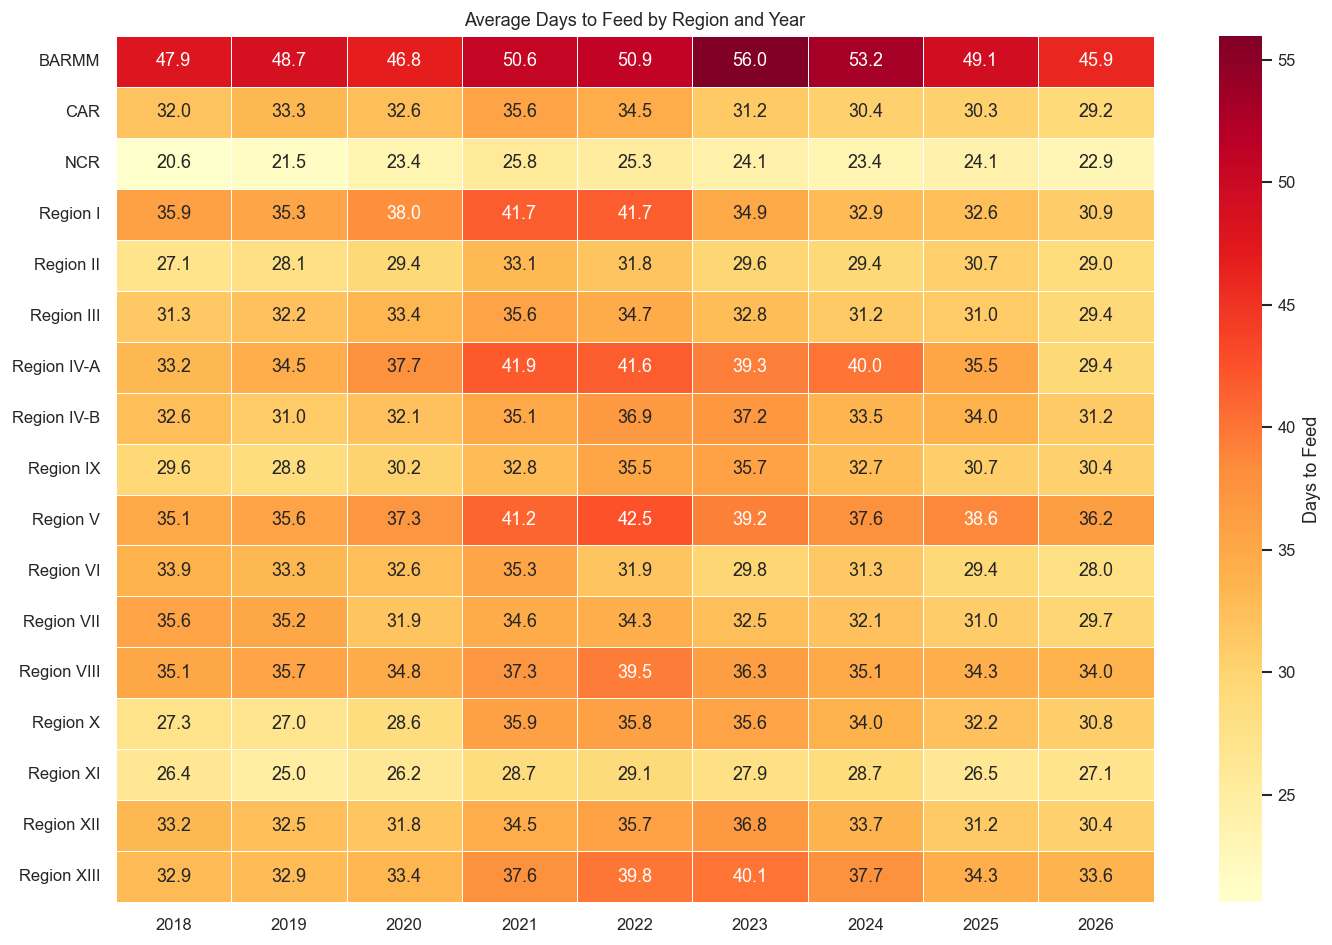

In [5]:
df["year"] = df["date"].dt.year
pivot = df.groupby(["region", "year"])["days_to_feed"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Days to Feed"}, ax=ax)
ax.set_title("Average Days to Feed by Region and Year")
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

## 5. Regional Box Plots — Latest Year

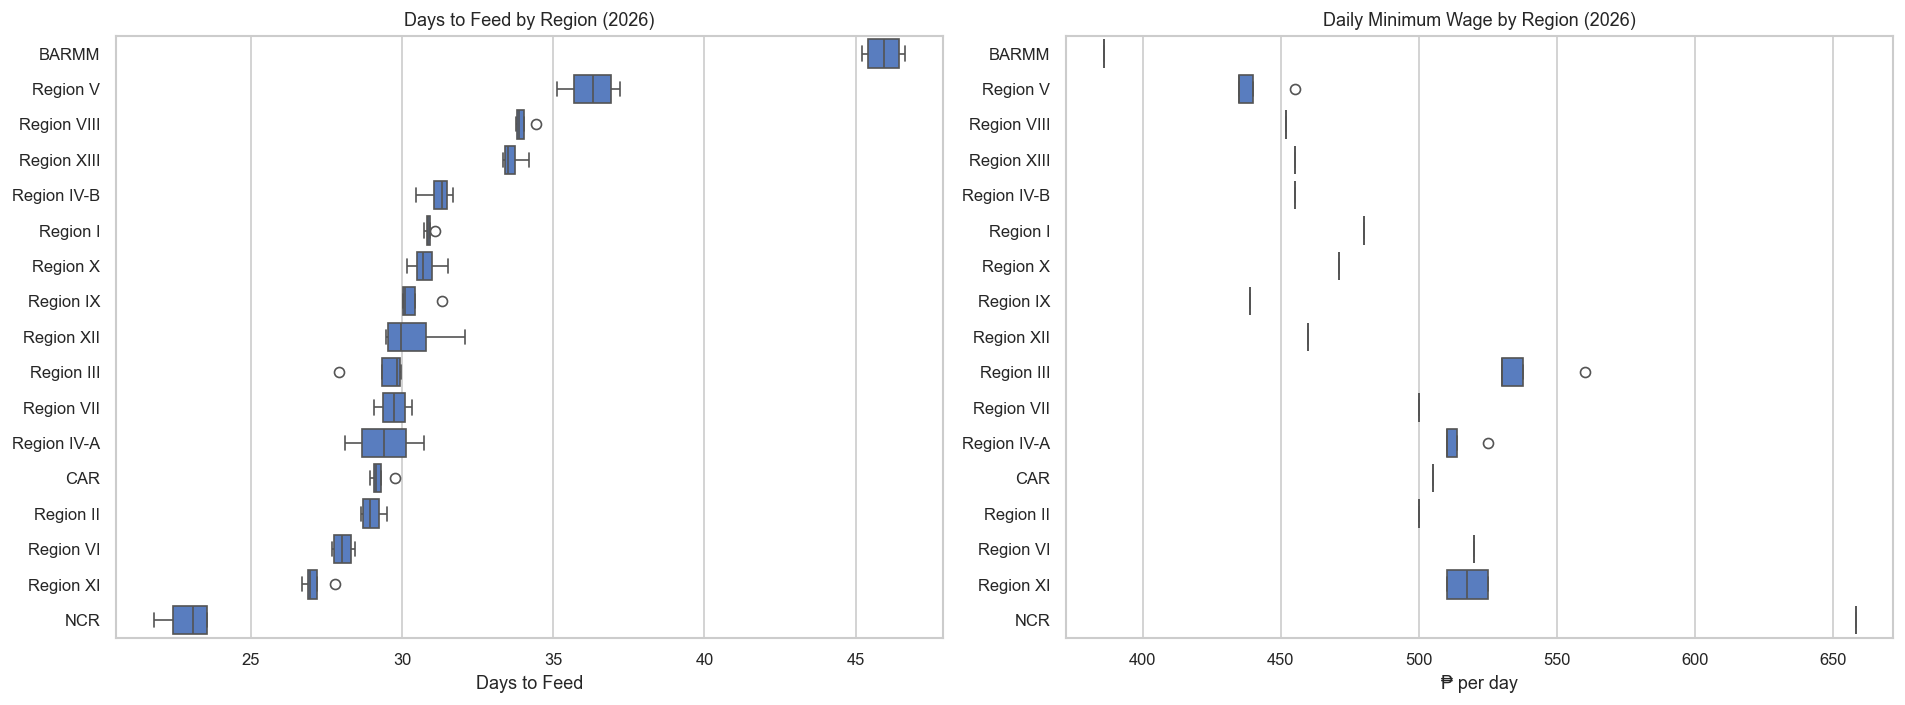

In [6]:
latest_year = df["year"].max()
recent = df[df["year"] == latest_year]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

order = recent.groupby("region")["days_to_feed"].median().sort_values(ascending=False).index
sns.boxplot(data=recent, y="region", x="days_to_feed", order=order, ax=ax1)
ax1.set_title(f"Days to Feed by Region ({latest_year})")
ax1.set_xlabel("Days to Feed")
ax1.set_ylabel("")

sns.boxplot(data=recent, y="region", x="daily_wage", order=order, ax=ax2)
ax2.set_title(f"Daily Minimum Wage by Region ({latest_year})")
ax2.set_xlabel("₱ per day")
ax2.set_ylabel("")

fig.tight_layout()
plt.show()

## 6. Correlation Matrix

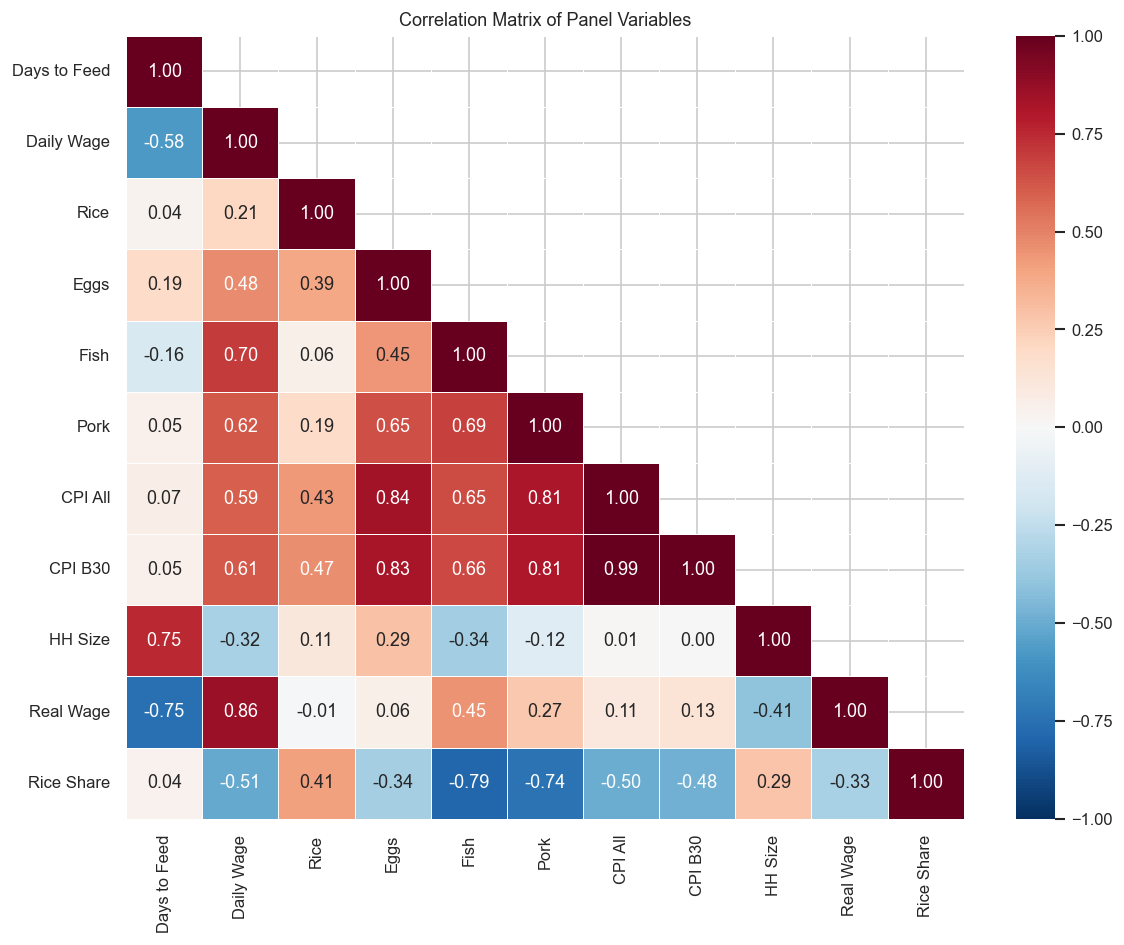

In [7]:
corr_cols = ["days_to_feed", "daily_wage", "rice_price", "egg_price", "fish_price",
             "pork_price", "cpi_all", "cpi_b30", "household_size", "real_wage", "rice_share"]
corr_labels = {
    "days_to_feed": "Days to Feed",
    "daily_wage": "Daily Wage",
    "rice_price": "Rice",
    "egg_price": "Eggs",
    "fish_price": "Fish",
    "pork_price": "Pork",
    "cpi_all": "CPI All",
    "cpi_b30": "CPI B30",
    "household_size": "HH Size",
    "real_wage": "Real Wage",
    "rice_share": "Rice Share",
}

corr = df[corr_cols].corr()
corr.index = [corr_labels.get(c, c) for c in corr.index]
corr.columns = [corr_labels.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix of Panel Variables")
fig.tight_layout()
plt.show()

## 7. Scatter Plots — Key Relationships with Days to Feed

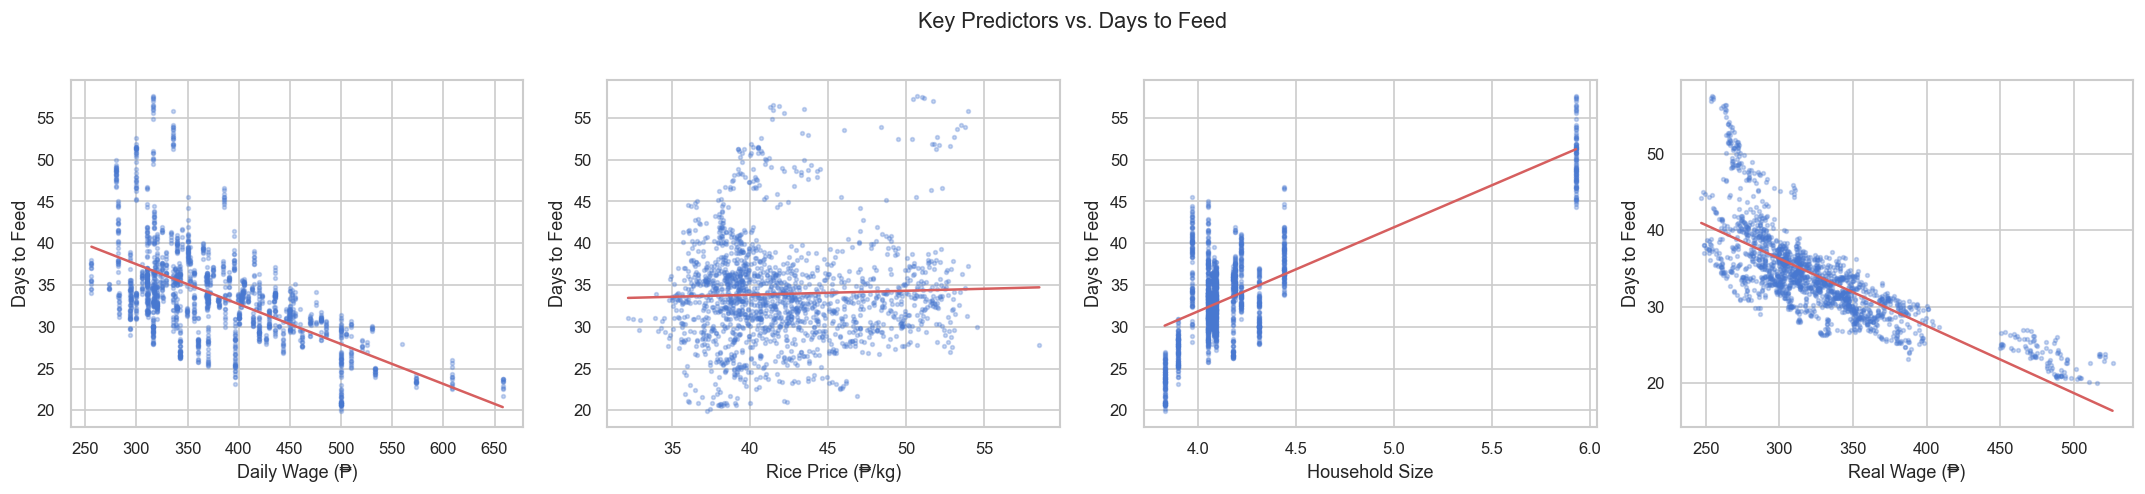

In [8]:
scatter_vars = [("daily_wage", "Daily Wage (₱)"),
                ("rice_price", "Rice Price (₱/kg)"),
                ("household_size", "Household Size"),
                ("real_wage", "Real Wage (₱)")]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (var, label) in zip(axes, scatter_vars):
    ax.scatter(df[var], df["days_to_feed"], s=5, alpha=0.3)
    z = np.polyfit(df[var].dropna(), df.loc[df[var].notna(), "days_to_feed"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x_line, p(x_line), "r-", linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel("Days to Feed")

fig.suptitle("Key Predictors vs. Days to Feed", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 8. Outlier Analysis

In [9]:
# IQR-based outlier detection for days_to_feed
Q1 = df["days_to_feed"].quantile(0.25)
Q3 = df["days_to_feed"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df[(df["days_to_feed"] < lower) | (df["days_to_feed"] > upper)]
print(f"Days to Feed — IQR bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers: {len(outliers)} / {len(df)} ({100*len(outliers)/len(df):.1f}%)")

if len(outliers) > 0:
    print("\nOutlier breakdown by region:")
    print(outliers.groupby("region")["days_to_feed"].agg(["count", "mean", "min", "max"]).sort_values("count", ascending=False))

# Summary statistics by region
print("\n\nSummary: Days to Feed by Region")
summary = df.groupby("region")["days_to_feed"].agg(["mean", "std", "min", "max"]).round(2)
summary = summary.sort_values("mean", ascending=False)
print(summary.to_string())

Days to Feed — IQR bounds: [21.4, 45.3]
Outliers: 118 / 1700 (6.9%)

Outlier breakdown by region:
             count       mean      min      max
region                                         
BARMM           94  50.557795  45.2896  57.6041
NCR             20  20.731145  19.9466  21.1106
Region V         3  46.630167  46.4988  46.7403
Region IV-A      1  45.556600  45.5566  45.5566


Summary: Days to Feed by Region
              mean   std    min    max
region                                
BARMM        50.22  3.40  44.34  57.60
Region V     38.30  2.74  33.83  46.74
Region IV-A  37.63  4.14  28.12  45.56
Region I     36.41  3.74  30.72  45.06
Region XIII  35.99  3.01  30.88  41.13
Region VIII  35.93  1.84  33.24  41.95
Region IV-B  33.93  2.35  29.06  38.91
Region XII   33.56  2.27  28.46  39.60
Region VII   33.25  2.32  28.07  37.79
Region III   32.63  2.01  27.92  37.15
CAR          32.36  2.08  28.85  36.67
Region VI    32.03  2.60  27.25  37.05
Region X     31.99  3.72  26.27  3